In [1]:
import omama as O

In [2]:
print(O)

<module 'omama' from '/home/a.kanamarlapudi001/projects/omama-proj/omama/__init__.py'>


In [3]:
print(dir(O))

['Algorithms', 'ConfusionMatrix', 'Data', 'DataHelper', 'DataLoader', 'DeepSight', 'DeepSightPost', 'Features', 'Image', 'Normalize', 'O', 'OmamaLoader', 'Scanner', 'SimpleNamespace', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'algorithms', 'analysis', 'confusion_matrix', 'data', 'data_helper', 'deep_sight', 'dicom', 'feature_extractor', 'features', 'glob', 'helpers', 'io', 'loaders', 'mpl', 'normalizations', 'np', 'omama', 'os', 'pickle', 'plt', 'scanner', 'slurm_job_files', 'time']


In [2]:
import sys
import time
sys.path.insert(0,'../..')
import omama as O

In [3]:
omama_loader = O.OmamaLoader()
data = O.Data(data_loader=omama_loader, load_cache=True)



Loading config data from ini file
DataLoader type is:  <class 'omama.loaders.omama_loader.OmamaLoader'>


In [5]:
mlo_img = O.DataHelper.get(image='DXm.2.25.106924144890407873251702717161766133956')



In [6]:
mlo_img

namespace(filePath='/raid/data01/deephealth/dh_dh0new/2.25.151222280059972160195646752408514211111/DXm.2.25.106924144890407873251702717161766133956',
          SOPInstanceUID='2.25.106924144890407873251702717161766133956',
          StudyInstanceUID='2.25.151222280059972160195646752408514211111',
          PatientID='DHTVBOQZ1OMQ',
          InstanceNumber="73",
          label='IndexCancer',
          imageLaterality='L',
          shape=(2457, 1996),
          metadata=Dataset.file_meta -------------------------------
                   (0002, 0000) File Meta Information Group Length  UL: 192
                   (0002, 0001) File Meta Information Version       OB: b'\x00\x01'
                   (0002, 0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
                   (0002, 0003) Media Storage SOP Instance UID      UI: 2.25.106924144890407873251702717161766133956
                   (0002, 0010) Transfer Syntax UID               

In [11]:
cc_img = O.DataHelper.get(image='DXm.2.25.173803440485307451614987519907264671779')

In [12]:
cc_img


namespace(filePath='/raid/data01/deephealth/dh_dh0new/2.25.151222280059972160195646752408514211111/DXm.2.25.173803440485307451614987519907264671779',
          SOPInstanceUID='2.25.173803440485307451614987519907264671779',
          StudyInstanceUID='2.25.151222280059972160195646752408514211111',
          PatientID='DHTVBOQZ1OMQ',
          InstanceNumber="61",
          label='IndexCancer',
          imageLaterality='L',
          shape=(2457, 1996),
          metadata=Dataset.file_meta -------------------------------
                   (0002, 0000) File Meta Information Group Length  UL: 192
                   (0002, 0001) File Meta Information Version       OB: b'\x00\x01'
                   (0002, 0002) Media Storage SOP Class UID         UI: Digital Mammography X-Ray Image Storage - For Presentation
                   (0002, 0003) Media Storage SOP Instance UID      UI: 2.25.173803440485307451614987519907264671779
                   (0002, 0010) Transfer Syntax UID               

In [13]:
#this is to predict cc image
pred = O.DeepSight.run([cc_img], timing=True)

Time to parse SOP UIDs:  5.9604644775390625e-06
Time to check cache:  0.9574193954467773
...took 0.9932527542114258


In [14]:
pred


{'2.25.173803440485307451614987519907264671779': {'coords': [336.0,
   1224.0,
   486.0,
   1350.0],
  'score': 0.65712571144104,
  'errors': None}}

type of data:  <class 'omama.data.Data'>
bb: [336, 1224, 486, 1350]


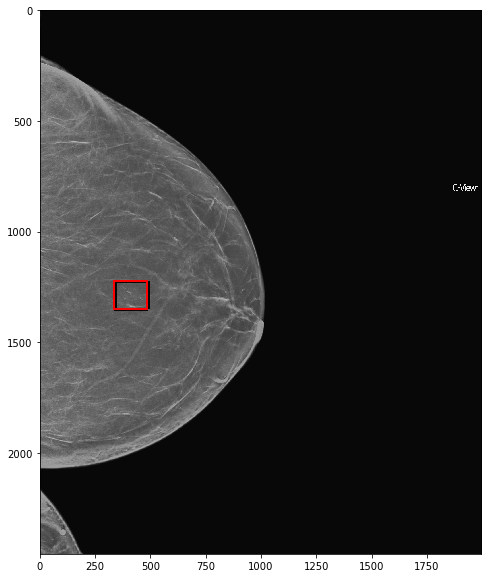

In [16]:
O.DataHelper.view(image=cc_img, roi_coords=pred['2.25.173803440485307451614987519907264671779']['coords'])

In [11]:
#this is to predict the mlo image
pred = O.DeepSight.run([mlo_img], timing=True)

Time to parse SOP UIDs:  4.76837158203125e-06
Time to check cache:  0.6991350650787354
...took 0.7416825294494629


In [13]:
pred


{'2.25.106924144890407873251702717161766133956': {'coords': [324.0,
   1213.0,
   467.0,
   1330.0],
  'score': 0.7945311069488525,
  'errors': None}}

type of data:  <class 'omama.data.Data'>
bb: [324, 1213, 467, 1330]


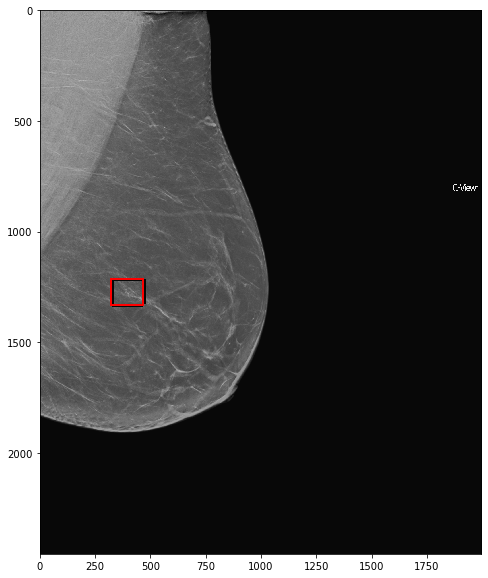

In [10]:
O.DataHelper.view(image=mlo_img, roi_coords=pred['2.25.106924144890407873251702717161766133956']['coords'])

In [14]:
random_images = O.DataHelper.get2D(N=60, cancer=True, randomize=True, timing=True, config_num=35)

Loading config data from ini file
DataLoader type is:  <class 'omama.loaders.omama_loader.OmamaLoader'>
get2D                    ...took    24.806103 seconds


/home/a.kanamarlapudi001/projects/omama-proj/omama/helpers/data_helper.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(pixels)


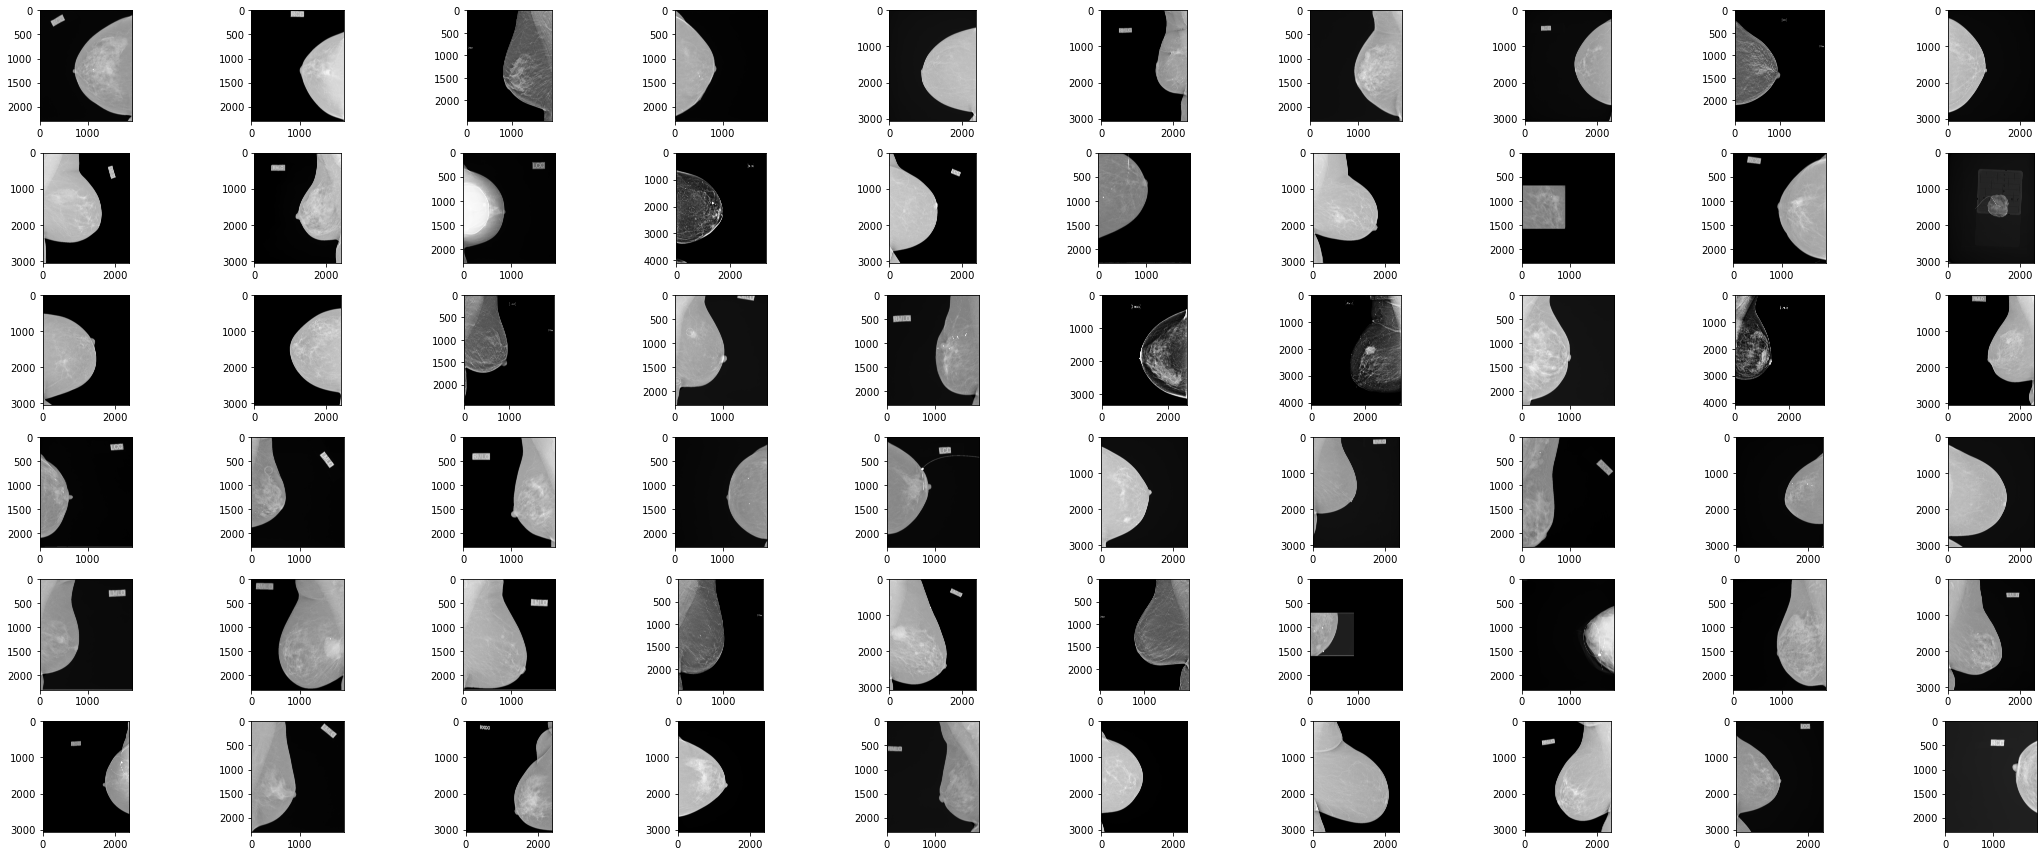

In [16]:
O.DataHelper.view_grid(random_images)